# Lorenz SINDy demo

**Informed hypothesis, then confirmation.** SINDy builds a candidate ODE from data. The **true Lorenz equations** are used only **after** fitting (`compare_to_truth`)—not as an input to discovery.

This notebook runs **Pareto STLSQ** with **minimum BIC** per target (`pareto_pick_mode='bic'`). Lorenz states and derivatives are **not** scaled before SINDy (`scaler_kind='identity'` via `lorenz_sindy_config_bic_standard`), and **library columns are not L2-normalized** (`normalize_library_columns=False`). Exact derivatives from the known RHS match a Brunton-style validation setup (clean $\dot{\mathbf{x}}$).


In [1]:
# Imports
import sys
from pathlib import Path

root = Path(".").resolve()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import os
import numpy as np
from lorenz.simulate import simulate_lorenz
from lorenz.model import build_lorenz_model, lorenz_sindy_config_bic_standard, lorenz_sindy_config_ensemble_bic_standard
from sindy.pipeline import run_sindy_pipeline_general
from idtools.compare_to_truth import compare_to_truth
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
# 1. Simulate Lorenz (paper-like: dt=0.001, 100 s, x0=(-8, 8, 27))
t, Z_phys = simulate_lorenz(
    t_span=(0.0, 100.0),
    dt=0.001,
    x0=(-8.0, 8.0, 27.0),
    random_state=42,
)
print(f"t: {t.size} points, dt ≈ {np.median(np.diff(t)):.6f}, Z_phys: {Z_phys.shape}")

t: 100001 points, dt ≈ 0.001000, Z_phys: (100001, 3)


In [3]:
# 2. Model, budget, and exact derivatives (for Lorenz)
model = build_lorenz_model()
budget = {
    "x": {"lin": 2, "trig": 0, "inv": 0, "sat": 0},
    "y": {"lin": 2, "trig": 0, "inv": 0, "sat": 0},
    "z": {"lin": 2, "trig": 0, "inv": 0, "sat": 0},
}
Z_dot_phys = np.column_stack([
    model.rhs_lambdified[i](*Z_phys.T) for i in range(len(model.rhs_lambdified))
])

## Pipeline: Pareto + BIC (unscaled state)

`lorenz_sindy_config_bic_standard()` uses **no state/derivative scaling** (`scaler_kind='identity'`) and **no Θ column normalization** before STLSQ. **BIC** selects along the Pareto front. Outputs go to `outputs/lorenz/bic_standard/`.


/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


=== Excitation Report ===
OK: True (data_ok=True, theta_ok=True)

Data excitation:
- State std ratio (max/median)=1.0 → maxabs OK (default)

Theta excitation:
- Theta shape: 100001 x 10, cond=8.552e+03, eff_rank=10 (1.00 frac)
- Library col norm ratio (max/median)=7.7 → raw OK (paper-like default)
- Pseudo-constant features (low CV): 1 (showing up to 10)
  1

Warnings:
- Theta excitation: 1 pseudo-constant features (low CV).


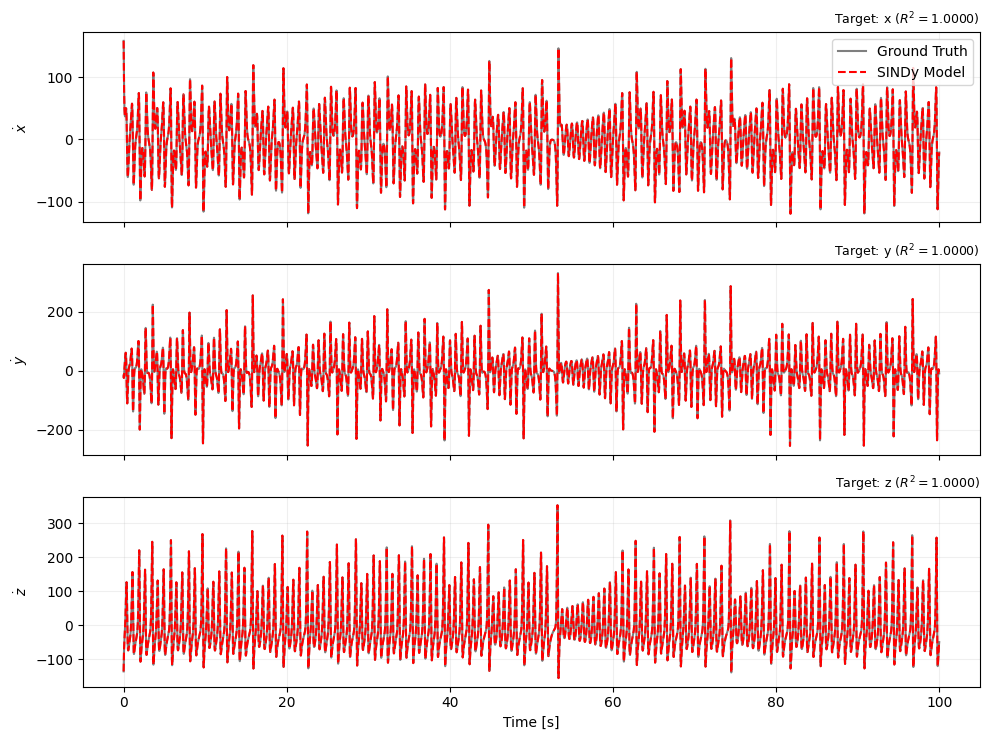

/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


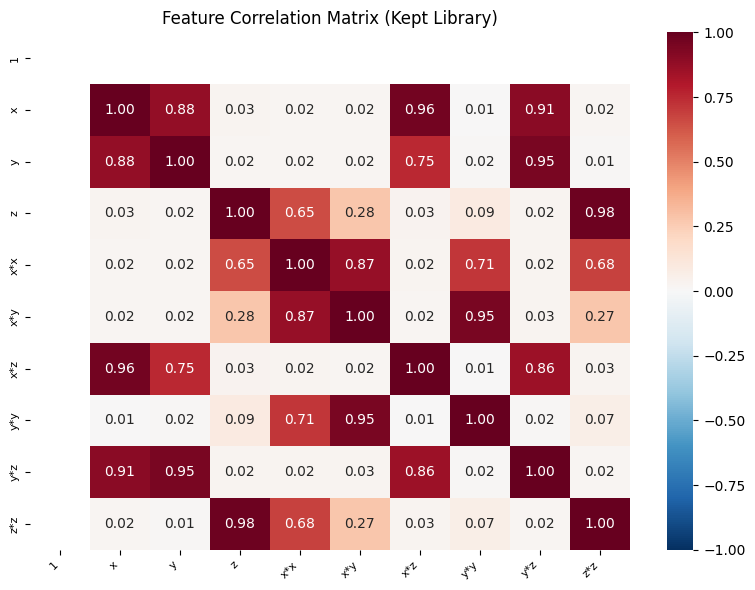

R2(mean): 1.0000, RMSE: 8.668e-14
R² per equation (dx, dy, dz): x=1.0000, y=1.0000, z=1.0000
Discovered equations:
  dx/dt = -10.0*x + 10.0*y
  dy/dt = -x*z + 28.0*x - y
  dz/dt = x*y - 2.6667*z

  TRUE vs DISCOVERED (structure recovery vs curve fitting)

True equations (from model):
  dx/dt = -10.0*x + 10.0*y
  dy/dt = x*(28.0 - z) - y
  dz/dt = x*y - 2.66666666666667*z

Discovered equations:
  dx/dt = -10.0*x + 10.0*y
  dy/dt = -x*z + 28.0*x - y
  dz/dt = x*y - 2.6667*z

Coefficient comparison (physical units, same library terms):
  Correlation(true, discovered) = 1.0000
  Mean relative error (on true nonzero terms) = 0.0000
  Max relative error (on true nonzero terms)  = 0.0000

  -> Strong coefficient agreement: suggests structure recovery, not just curve fitting.



/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'xi_true': array([[-1.00000000e+01,  2.80000000e+01, -2.13179279e-13],
        [ 1.00000000e+01, -1.00000000e+00,  1.24805980e-13],
        [-1.88975845e-13,  1.42943341e-12, -2.66666667e+00],
        [ 1.55530054e-14, -1.42817349e-13,  1.00000000e+00],
        [-2.56131602e-14, -1.00000000e+00,  6.40413568e-15]]),
 'xi_disc': array([[-10.        ,  28.        ,   0.        ],
        [ 10.        ,  -1.        ,   0.        ],
        [  0.        ,   0.        ,  -2.66666667],
        [  0.        ,   0.        ,   1.        ],
        [  0.        ,  -1.        ,   0.        ]]),
 'coef_correlation': 1.0,
 'rel_errors': array([[9.53903623e-14, 9.50350909e-14,            nan],
        [5.50670620e-14, 6.13953333e-13,            nan],
        [           nan,            nan, 1.55642166e-12],
        [           nan,            nan, 4.50528503e-13],
        [           nan, 6.06181771e-14,            nan]]),
 'mean_rel_error_nz': 4.181448837732219e-13,
 'max_rel_error_nz': 1.556421658

In [4]:
output_dir = "outputs/lorenz/bic_standard/"
os.makedirs(output_dir, exist_ok=True)

lorenz_cfg = lorenz_sindy_config_bic_standard()
res = run_sindy_pipeline_general(
    t=t,
    Z_phys=Z_phys,
    model=model,
    budget=budget,
    config=lorenz_cfg,
    Z_dot_phys=Z_dot_phys,
    run_diagnostics=True,
    output_dir=output_dir,
)

val = res["validation"]
print(f"R2(mean): {val['r2_mean']:.4f}, RMSE: {val['rmse']:.4g}")
r2b = val.get("r2_by_state")
if r2b is not None:
    r2b = np.asarray(r2b).ravel()
    print(f"R² per equation (dx, dy, dz): x={r2b[0]:.4f}, y={r2b[1]:.4f}, z={r2b[2]:.4f}")
print("Discovered equations:")
for name, expr in res["fit"]["equations"].items():
    print(f"  d{name}/dt = {expr}")

compare_to_truth(res, verbose=True)


### BIC selection visualised

Two-panel figure: Pareto frontier (NMSE vs complexity) and BIC score vs complexity.
The red star marks the minimum-BIC model. The true Lorenz system has 7 nonzero
coefficients across three equations, so BIC should select around k=7 and reject
denser candidates despite their lower MSE.

In [ ]:
from sindy.pareto import plot_bic_selection

fig, _ = plot_bic_selection(
    res["fit"],
    title="Lorenz system — BIC selection",
    out_path=output_dir + "bic_selection.png",
)
plt.show()

## Pareto ensemble + BIC (same scaling)

After the single-run Pareto front, **bootstrap ensemble STLSQ**: each draw uses 80% of rows, selects the **BIC**-best model on that draw’s Pareto front, then **median**-aggregates coefficients across draws. This often stabilizes coefficients under **collinearity**. Outputs: `outputs/lorenz/ensemble_bic_standard/`.


/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


=== Excitation Report ===
OK: True (data_ok=True, theta_ok=True)

Data excitation:
- State std ratio (max/median)=1.0 → maxabs OK (default)

Theta excitation:
- Theta shape: 100001 x 10, cond=8.552e+03, eff_rank=10 (1.00 frac)
- Library col norm ratio (max/median)=7.7 → raw OK (paper-like default)
- Pseudo-constant features (low CV): 1 (showing up to 10)
  1

Warnings:
- Theta excitation: 1 pseudo-constant features (low CV).


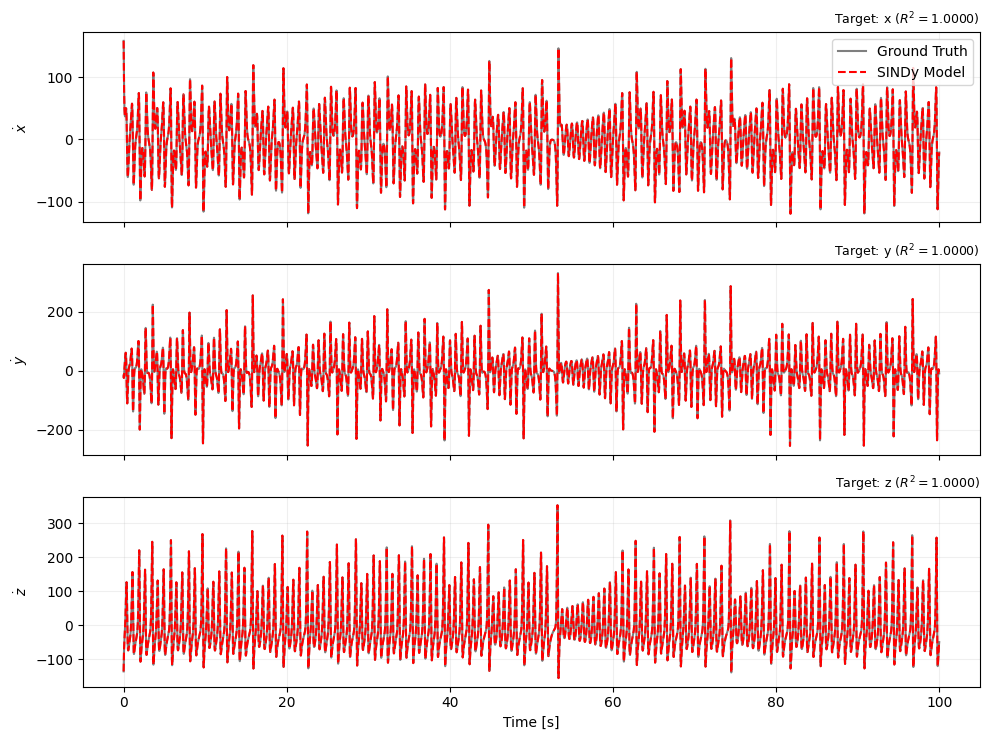

/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


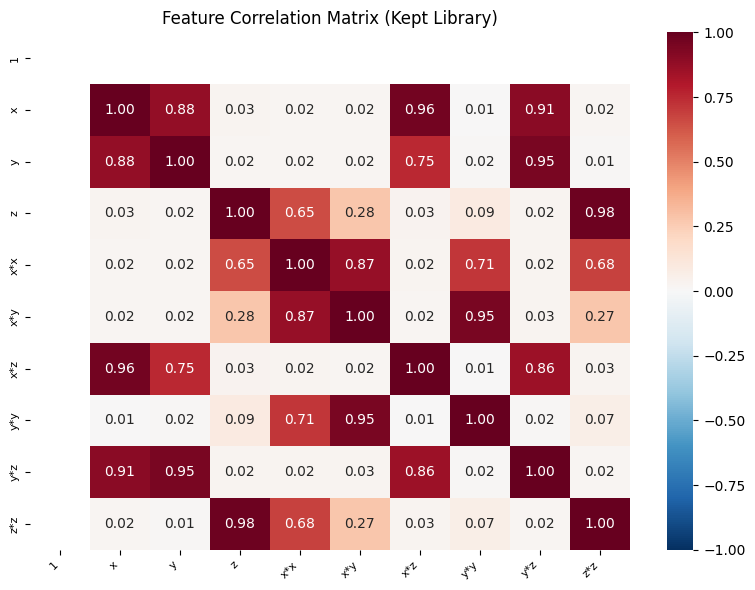

[ensemble] R2(mean): 1.0000, RMSE: 1.164e-13
[ensemble] Discovered equations:
  dx/dt = -10.0*x + 10.0*y
  dy/dt = -x*z + 28.0*x - y
  dz/dt = x*y - 2.6667*z
[ensemble] inclusion_probs: min=0.000, max=1.000

  TRUE vs DISCOVERED (structure recovery vs curve fitting)

True equations (from model):
  dx/dt = -10.0*x + 10.0*y
  dy/dt = x*(28.0 - z) - y
  dz/dt = x*y - 2.66666666666667*z

Discovered equations:
  dx/dt = -10.0*x + 10.0*y
  dy/dt = -x*z + 28.0*x - y
  dz/dt = x*y - 2.6667*z

Coefficient comparison (physical units, same library terms):
  Correlation(true, discovered) = 1.0000
  Mean relative error (on true nonzero terms) = 0.0000
  Max relative error (on true nonzero terms)  = 0.0000

  -> Strong coefficient agreement: suggests structure recovery, not just curve fitting.



/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ksommerk/clean_env/new_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{'xi_true': array([[-1.00000000e+01,  2.80000000e+01, -2.13179279e-13],
        [ 1.00000000e+01, -1.00000000e+00,  1.24805980e-13],
        [-1.88975845e-13,  1.42943341e-12, -2.66666667e+00],
        [ 1.55530054e-14, -1.42817349e-13,  1.00000000e+00],
        [-2.56131602e-14, -1.00000000e+00,  6.40413568e-15]]),
 'xi_disc': array([[-10.        ,  28.        ,   0.        ],
        [ 10.        ,  -1.        ,   0.        ],
        [  0.        ,   0.        ,  -2.66666667],
        [  0.        ,   0.        ,   1.        ],
        [  0.        ,  -1.        ,   0.        ]]),
 'coef_correlation': 1.0,
 'rel_errors': array([[9.62785407e-14, 9.59232693e-14,            nan],
        [5.54223334e-14, 5.71764858e-13,            nan],
        [           nan,            nan, 1.55658819e-12],
        [           nan,            nan, 4.50417481e-13],
        [           nan, 6.30606678e-14,            nan]]),
 'mean_rel_error_nz': 4.127793344990605e-13,
 'max_rel_error_nz': 1.556588191

In [5]:
output_dir_ens = "outputs/lorenz/ensemble_bic_standard/"
os.makedirs(output_dir_ens, exist_ok=True)

cfg_ens = lorenz_sindy_config_ensemble_bic_standard(ensemble_B=50, ensemble_frac=0.8)
res_ens = run_sindy_pipeline_general(
    t=t,
    Z_phys=Z_phys,
    model=model,
    budget=budget,
    config=cfg_ens,
    Z_dot_phys=Z_dot_phys,
    run_diagnostics=True,
    output_dir=output_dir_ens,
)

val_e = res_ens["validation"]
print(f"[ensemble] R2(mean): {val_e['r2_mean']:.4f}, RMSE: {val_e['rmse']:.4g}")
print("[ensemble] Discovered equations:")
for name, expr in res_ens["fit"]["equations"].items():
    print(f"  d{name}/dt = {expr}")

inc = res_ens["fit"].get("inclusion_probs")
if inc is not None:
    inc = np.asarray(inc)
    print(f"[ensemble] inclusion_probs: min={float(inc.min()):.3f}, max={float(inc.max()):.3f}")

compare_to_truth(res_ens, verbose=True)


### 3D integrated trajectories (true vs SINDy)

Forward-integrate the **discovered** ODE from the same IC as the data; compare to the **reference** trajectory and a **true Lorenz** re-integration (sanity check). Uses a subsampled time grid for speed (`t_subsample_step`).


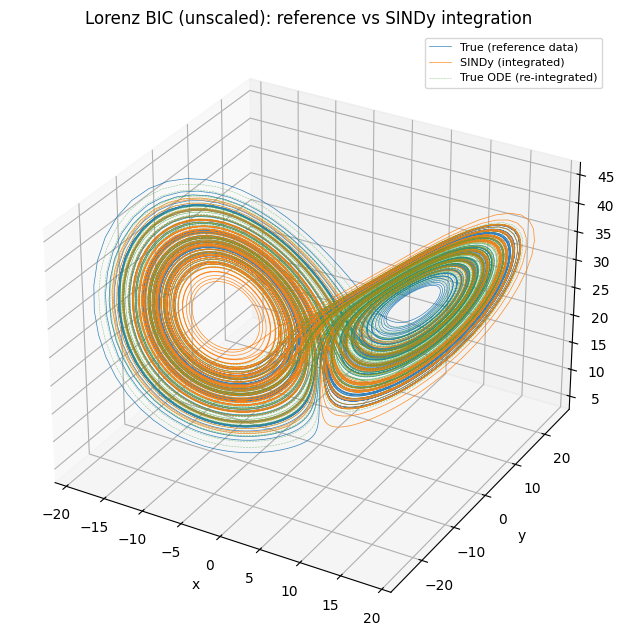

RMSE(state) on subsampled grid: 11.6


In [6]:
from lorenz.integrated import integrated_3d_comparison

T_STRIDE = 10  # set to 1 for full 10^5-point grid (slow)

out = integrated_3d_comparison(
    res,
    t,
    Z_phys,
    out_path="outputs/lorenz/bic_standard/lorenz_3d_true_vs_sindy.png",
    title="Lorenz BIC (unscaled): reference vs SINDy integration",
    t_subsample_step=T_STRIDE,
)
plt.show()
print(f"RMSE(state) on subsampled grid: {out['rmse_state']:.4g}")


**Ensemble** run — same 3D comparison (saved under `outputs/lorenz/ensemble_bic_standard/`).


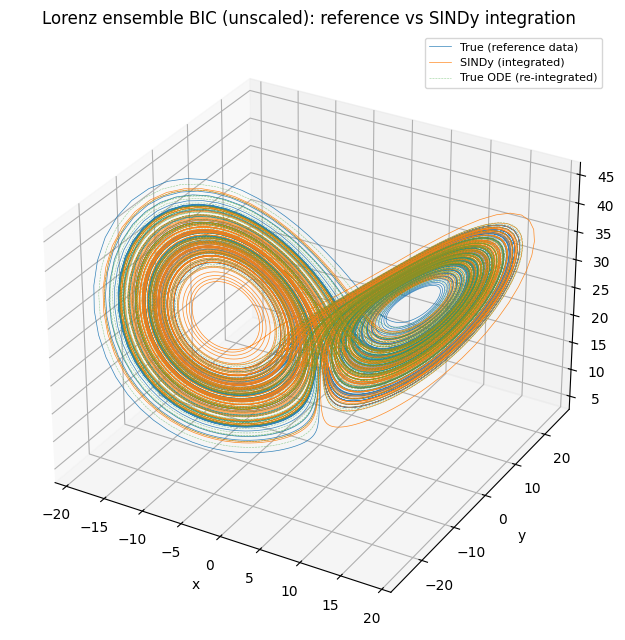

[ensemble] RMSE(state): 11.05


In [7]:
T_STRIDE = 10
out_ens = integrated_3d_comparison(
    res_ens,
    t,
    Z_phys,
    out_path="outputs/lorenz/ensemble_bic_standard/lorenz_3d_true_vs_sindy.png",
    title="Lorenz ensemble BIC (unscaled): reference vs SINDy integration",
    t_subsample_step=T_STRIDE,
)
plt.show()
print(f"[ensemble] RMSE(state): {out_ens['rmse_state']:.4g}")
